[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vittot/ISCB-NLP-Course-2026/blob/main/notebooks/ex2_weak_supervision_classification.ipynb)

# EX 2 Classification from cluster-derived (weak) labels

**Goal.** In EX 1 we clustered short diagnosis phrases and identified clean clusters
for two macro-categories: **cardiac** and **respiratory** conditions. Here we turn those
cluster memberships into *weak labels* for the full clinical notes, train classifiers on
them, and see how well that actually works -- both by the weak labels' own standard, and
against real labels (a separate cardiac/respiratory
annotation of all 2667 notes, built from rules plus manual review, kept independent of the
clustering pipeline).

Two independent binary tasks: **cardiac vs not**, **respiratory vs not** (not mutually
exclusive -- a note can be both). Two model families: **TF-IDF + logistic regression**
(vocabulary-based baseline) and a **fine-tuned Transformer** (Bio_ClinicalBERT).

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
RANDOM_STATE = 0

## 2. Load data and derive weak labels

Two label sources for every one of the 2667 notes:

- **Weak labels**: does this note's diagnosis-phrase cluster (from block 2's HDBSCAN
  clustering) fall in the set of clusters we identified as "cardiac" or "respiratory"?
  Notes with no extracted phrase, or a phrase that landed in noise or an unrelated
  cluster, get a weak label of 0 for both -- the "broad negative pool" we discussed:
  realistic, but means many genuinely cardiac/respiratory notes will be *mislabeled* as
  negative simply because the clustering pipeline didn't catch them.
- **Real labels**: a separate cardiac/respiratory annotation covering all 2667 notes
  (keyword/negation rules for the clear-cut cases, manual reading for everything the
  rules couldn't decide -- 261 notes). Not perfect, but built independently of the
  clustering pipeline, so it's a meaningful check on the weak labels rather than a
  circular one.

In [2]:
df = pd.read_csv("data/dyspnea_weak_and_real_labels.csv", dtype={"document_id": str})
print(df.shape)
df[["cardiac", "respiratory", "weak_cardiac", "weak_respiratory"]].sum()

(2667, 9)


cardiac             847
respiratory         777
weak_cardiac        225
weak_respiratory    123
dtype: int64

### 2.1 How much do the weak labels actually agree with the real ones?

Worth checking *before* training anything -- if the weak labels are a poor stand-in for
the real ones, that's exactly the gap we should expect the classifier's real-world
performance to inherit.

In [3]:
for task in ["cardiac", "respiratory"]:
    weak_col = f"weak_{task}"
    ct = pd.crosstab(df[weak_col], df[task], rownames=[f"weak_{task}"], colnames=[f"real_{task}"])
    tp = ct.loc[1, 1] if (1 in ct.index and 1 in ct.columns) else 0
    fp = ct.loc[1, 0] if (1 in ct.index and 0 in ct.columns) else 0
    fn = ct.loc[0, 1] if (0 in ct.index and 1 in ct.columns) else 0
    precision = tp / (tp + fp) if (tp + fp) else float("nan")
    recall = tp / (tp + fn) if (tp + fn) else float("nan")
    print(f"=== {task} ===")
    print(ct)
    print(f"weak label vs real label -- precision: {precision:.1%}, recall: {recall:.1%}")
    print()

=== cardiac ===
real_cardiac     0    1
weak_cardiac           
0             1782  660
1               38  187
weak label vs real label -- precision: 83.1%, recall: 22.1%

=== respiratory ===
real_respiratory     0    1
weak_respiratory           
0                 1874  670
1                   16  107
weak label vs real label -- precision: 87.0%, recall: 13.8%



As expected: weak-label **precision is high** (when the weak label says "cardiac", it
usually is), but **recall is low** (it only catches a fraction of the real cases) --
the clustering pipeline only produces a weak label for notes whose diagnosis phrase
happened to land in one of our identified clean clusters, which is a small, biased
subset of all the ways a note can actually be cardiac or respiratory. This is the central
challenge block 3 is about: can a classifier trained on this narrow, high-precision
signal still generalize to the cases the weak labels themselves missed?

## 3. Evaluation methodology

**Cross-validation, not a single split**: with only 123-225 weak positives per task,
a single train/test split would make any one estimate noisy. We use 5-fold stratified CV
(stratified on the weak label, since that's what we train on) and pool out-of-fold
predictions across all 5 folds into one set of predictions covering all 2667 notes --
giving a single, more stable estimate per metric instead of 5 noisy per-fold numbers.

**Undersampling, training data only**: weak positives are a small minority (4.6-8.4% of
notes). We undersample the negatives *within each training fold* to a fixed ratio (4
negatives per positive) so the classifier doesn't just learn to always predict "negative"
-- but the *test* fold is left at its natural (imbalanced) class balance, since that's
what evaluation should reflect.

**Decision threshold, chosen without leakage.** A model fit on undersampled training
data (~20% positive) and then evaluated with a flat 0.5 cutoff on a test fold at the real,
far lower prevalence is comparing apples to oranges: 0.5 no longer means "50% chance of
positive on data like the test set" once training changed the class balance. Instead of
using 0.5 by default, we carve a small *inner* validation slice out of each outer training
fold (never touched by undersampling or fitting, and never overlapping the outer test
fold), sweep candidate thresholds on it, and keep the one that maximises F1 *against the
weak label* -- the only supervision we'd actually have at deployment time. That
fold-specific threshold, chosen with zero visibility into that fold's test data, is what
gets applied to the test fold. We still report the naive 0.5 cutoff alongside it, so the
size of the miscalibration effect is visible rather than just fixed silently.

In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

def undersample_indices(labels, neg_ratio=4, random_state=0):
    rng = np.random.RandomState(random_state)
    pos_idx = np.where(labels == 1)[0]
    neg_idx = np.where(labels == 0)[0]
    n_neg = min(len(neg_idx), len(pos_idx) * neg_ratio)
    sampled_neg = rng.choice(neg_idx, size=n_neg, replace=False)
    return np.concatenate([pos_idx, sampled_neg])

def pick_threshold(y_val, proba_val):
    """Threshold in [0.05, 0.95] maximising F1 on a validation slice -- chosen using
    only that slice, never the outer test fold."""
    candidates = np.linspace(0.05, 0.95, 19)
    scores = [f1_score(y_val, (proba_val >= t).astype(int), zero_division=0) for t in candidates]
    return float(candidates[int(np.argmax(scores))])

N_SPLITS = 5
NEG_RATIO = 4
INNER_VAL_SPLITS = 4  # 1/4 of each outer training fold held out for threshold selection

## 4. Baseline: TF-IDF + logistic regression

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

def run_tfidf_cv(texts, weak_labels, n_splits=N_SPLITS, neg_ratio=NEG_RATIO, random_state=RANDOM_STATE):
    oof_proba = np.zeros(len(texts))
    oof_threshold = np.full(len(texts), 0.5)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for fold, (train_idx, test_idx) in enumerate(skf.split(texts, weak_labels)):
        inner_skf = StratifiedKFold(n_splits=INNER_VAL_SPLITS, shuffle=True, random_state=random_state + fold)
        fit_rel, val_rel = next(inner_skf.split(train_idx, weak_labels[train_idx]))
        fit_idx, val_idx = train_idx[fit_rel], train_idx[val_rel]

        sub = undersample_indices(weak_labels[fit_idx], neg_ratio, random_state=random_state + fold)
        fit_idx_sub = fit_idx[sub]

        vectorizer = TfidfVectorizer(stop_words="english", max_features=20000, ngram_range=(1, 2))
        X_fit = vectorizer.fit_transform(texts[fit_idx_sub])
        clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
        clf.fit(X_fit, weak_labels[fit_idx_sub])

        val_proba = clf.predict_proba(vectorizer.transform(texts[val_idx]))[:, 1]
        threshold = pick_threshold(weak_labels[val_idx], val_proba)

        oof_proba[test_idx] = clf.predict_proba(vectorizer.transform(texts[test_idx]))[:, 1]
        oof_threshold[test_idx] = threshold
        print(f"  fold {fold + 1}/{n_splits}: {len(fit_idx_sub)} fit rows "
              f"({weak_labels[fit_idx_sub].sum()} positive), tuned threshold={threshold:.2f}")
    return oof_proba, oof_threshold

texts = df["clinical_note"].values
tfidf_oof, tfidf_threshold = {}, {}
for task in ["cardiac", "respiratory"]:
    print(f"=== TF-IDF + LogisticRegression: {task} ===")
    tfidf_oof[task], tfidf_threshold[task] = run_tfidf_cv(texts, df[f"weak_{task}"].values)

=== TF-IDF + LogisticRegression: cardiac ===


  fold 1/5: 675 fit rows (135 positive), tuned threshold=0.25


  fold 2/5: 675 fit rows (135 positive), tuned threshold=0.30


  fold 3/5: 675 fit rows (135 positive), tuned threshold=0.30


  fold 4/5: 675 fit rows (135 positive), tuned threshold=0.30


...

  fold 1/5: 365 fit rows (73 positive), tuned threshold=0.25


  fold 2/5: 365 fit rows (73 positive), tuned threshold=0.30


  fold 3/5: 370 fit rows (74 positive), tuned threshold=0.30


  fold 4/5: 370 fit rows (74 positive), tuned threshold=0.25


  fold 5/5: 365 fit rows (73 positive), tuned threshold=0.25


## 4.1 An even simpler baseline: Naive Bayes

TF-IDF + logistic regression is already a "simple" baseline relative to BERT, but it still
fits a weight per feature via gradient-based optimisation and implicitly captures
feature interactions through that fitting process. Multinomial Naive Bayes goes a step
further down in complexity: it assumes word counts are conditionally independent given
the class, and gets its class probabilities from nothing more than word-frequency ratios
counted directly off the training data -- there's no iterative optimisation at all,
training is just counting. It also normally runs on raw counts rather than TF-IDF weights,
so we swap in a `CountVectorizer`. If this baseline lands close to TF-IDF+LR or BERT,
that would say the task is dominated by a handful of individual, near-independent
keywords; if it lands clearly behind, that says the extra structure the other two
models capture -- feature interactions and (for BERT) context -- is actually earning its
keep.

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

def run_nb_cv(texts, weak_labels, n_splits=N_SPLITS, neg_ratio=NEG_RATIO, random_state=RANDOM_STATE):
    oof_proba = np.zeros(len(texts))
    oof_threshold = np.full(len(texts), 0.5)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for fold, (train_idx, test_idx) in enumerate(skf.split(texts, weak_labels)):
        inner_skf = StratifiedKFold(n_splits=INNER_VAL_SPLITS, shuffle=True, random_state=random_state + fold)
        fit_rel, val_rel = next(inner_skf.split(train_idx, weak_labels[train_idx]))
        fit_idx, val_idx = train_idx[fit_rel], train_idx[val_rel]

        sub = undersample_indices(weak_labels[fit_idx], neg_ratio, random_state=random_state + fold)
        fit_idx_sub = fit_idx[sub]

        vectorizer = CountVectorizer(stop_words="english", max_features=20000, ngram_range=(1, 2))
        X_fit = vectorizer.fit_transform(texts[fit_idx_sub])
        clf = MultinomialNB()
        clf.fit(X_fit, weak_labels[fit_idx_sub])

        val_proba = clf.predict_proba(vectorizer.transform(texts[val_idx]))[:, 1]
        threshold = pick_threshold(weak_labels[val_idx], val_proba)

        oof_proba[test_idx] = clf.predict_proba(vectorizer.transform(texts[test_idx]))[:, 1]
        oof_threshold[test_idx] = threshold
        print(f"  fold {fold + 1}/{n_splits}: {len(fit_idx_sub)} fit rows "
              f"({weak_labels[fit_idx_sub].sum()} positive), tuned threshold={threshold:.2f}")
    return oof_proba, oof_threshold

nb_oof, nb_threshold = {}, {}
for task in ["cardiac", "respiratory"]:
    print(f"=== Naive Bayes (CountVectorizer + MultinomialNB): {task} ===")
    nb_oof[task], nb_threshold[task] = run_nb_cv(texts, df[f"weak_{task}"].values)

=== Naive Bayes (CountVectorizer + MultinomialNB): cardiac ===


  fold 1/5: 675 fit rows (135 positive), tuned threshold=0.75


  fold 2/5: 675 fit rows (135 positive), tuned threshold=0.75


  fold 3/5: 675 fit rows (135 positive), tuned threshold=0.95


  fold 4/5: 675 fit rows (135 positive), tuned threshold=0.95


...

  fold 1/5: 365 fit rows (73 positive), tuned threshold=0.10


  fold 2/5: 365 fit rows (73 positive), tuned threshold=0.05


  fold 3/5: 370 fit rows (74 positive), tuned threshold=0.10


  fold 4/5: 370 fit rows (74 positive), tuned threshold=0.55


  fold 5/5: 365 fit rows (73 positive), tuned threshold=0.15


## 5. Fine-tuned Transformer: Bio_ClinicalBERT

In [7]:
import random
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

BERT_MODEL = "emilyalsentzer/Bio_ClinicalBERT"
MAX_LENGTH = 192
BATCH_SIZE = 8
EPOCHS = 2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

def set_seed(seed):
    """Seeds every source of randomness we touch for BERT fine-tuning, so a given
    fold/variant gives the same model init, batch order, and dropout pattern every run."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

class NotesDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.enc = tokenizer(list(texts), truncation=True, padding=True, max_length=max_length)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

C:\Users\vitto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [8]:
_tokenizer_cache = {}

def get_tokenizer():
    if "tok" not in _tokenizer_cache:
        _tokenizer_cache["tok"] = AutoTokenizer.from_pretrained(BERT_MODEL)
    return _tokenizer_cache["tok"]

def freeze_bert_layers(model, n_trainable_layers):
    """Freeze the embeddings and all but the last `n_trainable_layers` encoder layers.
    n_trainable_layers=None leaves everything trainable (full fine-tuning, the original
    behaviour); n_trainable_layers=0 freezes the whole encoder, leaving only the
    (randomly-initialised, always-trainable) classifier head -- a linear probe on frozen
    BERT features."""
    if n_trainable_layers is None:
        return
    for param in model.bert.embeddings.parameters():
        param.requires_grad = False
    layers = model.bert.encoder.layer
    n_freeze = max(len(layers) - n_trainable_layers, 0)
    for layer in layers[:n_freeze]:
        for param in layer.parameters():
            param.requires_grad = False

def fine_tune(train_texts, train_labels, n_trainable_layers=None, seed=0):
    set_seed(seed)
    tokenizer = get_tokenizer()
    model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2).to(DEVICE)
    freeze_bert_layers(model, n_trainable_layers)

    train_ds = NotesDataset(train_texts, train_labels, tokenizer)
    generator = torch.Generator()
    generator.manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=generator)

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=2e-5)

    model.train()
    for epoch in range(EPOCHS):
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            loss = model(**batch).loss
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
    return model

def bert_predict_proba(model, texts):
    tokenizer = get_tokenizer()
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch_texts = list(texts[i:i + BATCH_SIZE])
            enc = tokenizer(batch_texts, truncation=True, padding=True, max_length=MAX_LENGTH, return_tensors="pt").to(DEVICE)
            logits = model(**enc).logits
            probs.append(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
    return np.concatenate(probs)


def run_bert_cv(texts, weak_labels, n_trainable_layers=None, n_splits=N_SPLITS, neg_ratio=NEG_RATIO, random_state=RANDOM_STATE):
    oof_proba = np.zeros(len(texts))
    oof_threshold = np.full(len(texts), 0.5)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for fold, (train_idx, test_idx) in enumerate(skf.split(texts, weak_labels)):
        inner_skf = StratifiedKFold(n_splits=INNER_VAL_SPLITS, shuffle=True, random_state=random_state + fold)
        fit_rel, val_rel = next(inner_skf.split(train_idx, weak_labels[train_idx]))
        fit_idx, val_idx = train_idx[fit_rel], train_idx[val_rel]

        sub = undersample_indices(weak_labels[fit_idx], neg_ratio, random_state=random_state + fold)
        fit_idx_sub = fit_idx[sub]

        model = fine_tune(texts[fit_idx_sub], weak_labels[fit_idx_sub],
                           n_trainable_layers=n_trainable_layers, seed=random_state + fold)

        val_proba = bert_predict_proba(model, texts[val_idx])
        threshold = pick_threshold(weak_labels[val_idx], val_proba)

        oof_proba[test_idx] = bert_predict_proba(model, texts[test_idx])
        oof_threshold[test_idx] = threshold
        del model
        torch.cuda.empty_cache()
        print(f"  fold {fold + 1}/{n_splits}: {len(fit_idx_sub)} fit rows, tuned threshold={threshold:.2f}")
    return oof_proba, oof_threshold

### 5.1 How much of BERT actually needs to be fine-tuned?

Full fine-tuning updates all 12 encoder layers plus the embeddings -- effectively
re-training the whole network, at the cost of a full backward pass through every layer for
every batch. The lower layers of a pretrained Transformer tend to encode fairly generic
language features (e.g. Wikipedia dumps, PubMed, or a mix of the two, depending on the
checkpoint), while the upper layers are usually the ones that end up encoding a downstream
task. So a natural question: do we actually need to touch all 12 layers, or would updating
just the last few (or even none, only the classifier head) get us most of the way there,
for a fraction of the compute?

We compare four variants, freezing everything except the last `k` encoder layers (the
classifier head on top is always trainable, since it's randomly initialised and has no
existing task-relevant weights to preserve):

- **linear probe (0 layers)**: the entire pretrained encoder is frozen; only the
  classification head is trained. This tells us how good BERT's *off-the-shelf*
  representation already is for this task, with zero adaptation.
- **last 1 layer** / **last 3 layers**: partial fine-tuning, a common compromise when
  compute or data is limited.
- **full fine-tune (12 layers)**: the original setup from section 5, all layers trainable.

Everything else (data, folds, undersampling, threshold selection) is identical across
variants, and every run is now seeded (`set_seed` in section 5), so differences between
variants reflect the freezing choice, not run-to-run noise.

In [9]:
import pickle
from pathlib import Path

BERT_VARIANTS = {
    "linear probe (0 layers)": 0,
    "last 1 layer": 1,
    "last 3 layers": 3,
    "full fine-tune (12 layers)": None,
}

BERT_CACHE_PATH = Path("data/bert_variant_cache.pkl")

if BERT_CACHE_PATH.exists():
    print(f"Loading cached BERT results from {BERT_CACHE_PATH} -- delete this file to force a re-run.")
    with open(BERT_CACHE_PATH, "rb") as f:
        bert_variant_oof, bert_variant_threshold = pickle.load(f)
else:
    bert_variant_oof = {name: {} for name in BERT_VARIANTS}
    bert_variant_threshold = {name: {} for name in BERT_VARIANTS}
    for variant_name, n_layers in BERT_VARIANTS.items():
        for task in ["cardiac", "respiratory"]:
            print(f"=== BERT [{variant_name}]: {task} ===")
            oof, thr = run_bert_cv(texts, df[f"weak_{task}"].values, n_trainable_layers=n_layers)
            bert_variant_oof[variant_name][task] = oof
            bert_variant_threshold[variant_name][task] = thr
    with open(BERT_CACHE_PATH, "wb") as f:
        pickle.dump((bert_variant_oof, bert_variant_threshold), f)
    print(f"Cached BERT results to {BERT_CACHE_PATH} for future re-runs.")

Loading cached BERT results from data\bert_variant_cache.pkl -- delete this file to force a re-run.


## 6. Results: weak-label performance vs real performance

Same out-of-fold predictions, scored twice: once against the weak labels the models were
*trained* on (this tells us how well each model fits the training signal), and once
against the real labels (this tells us how well it actually does at the task we care
about). The gap between the two is the practical cost of weak supervision.

In [10]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, average_precision_score

def compute_metrics(y_true, y_proba, threshold):
    """threshold can be a scalar (naive 0.5) or a per-row array (fold-tuned)."""
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba) if y_true.nunique() > 1 else float("nan"),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

model_runs = [
    ("TF-IDF + LogisticRegression", tfidf_oof, tfidf_threshold),
    ("Naive Bayes", nb_oof, nb_threshold),
]
for variant_name in BERT_VARIANTS:
    model_runs.append((f"BERT [{variant_name}]", bert_variant_oof[variant_name], bert_variant_threshold[variant_name]))

rows = []
for model_name, oof, tuned_threshold in model_runs:
    for task in ["cardiac", "respiratory"]:
        for label_type, label_col in [("weak", f"weak_{task}"), ("real", task)]:
            for threshold_name, threshold in [("fixed_0.5", 0.5), ("tuned_per_fold", tuned_threshold[task])]:
                m = compute_metrics(df[label_col], oof[task], threshold)
                rows.append({
                    "model": model_name, "task": task, "evaluated_against": label_type,
                    "threshold": threshold_name, **m,
                })

results = pd.DataFrame(rows)
results = results.sort_values(["task", "model", "evaluated_against", "threshold"]).reset_index(drop=True)
results.round(3)

,model,task,evaluated_against,threshold,precision,recall,f1,roc_auc,pr_auc
0,BERT [full fine-tune (12 layers)],cardiac,real,fixed_0.5,0.977,0.152,0.264,0.865,0.780
1,BERT [full fine-tune (12 layers)],cardiac,real,tuned_per_fold,0.859,0.394,0.540,0.865,0.780
2,BERT [full fine-tune (12 layers)],cardiac,weak,fixed_0.5,0.409,0.240,0.303,0.838,0.300
3,BERT [full fine-tune (12 layers)],cardiac,weak,tuned_per_fold,0.283,0.489,0.358,0.838,0.300
4,BERT [last 1 layer],cardiac,real,fixed_0.5,1.000,0.027,0.053,0.819,0.741
5,BERT [last 1 layer],cardiac,real,tuned_per_fold,0.817,0.380,0.519,0.819,0.741
6,BERT [last 1 layer],cardiac,weak,fixed_0.5,0.391,0.040,0.073,0.735,0.238
7,BERT [last 1 layer],cardiac,weak,tuned_per_fold,0.239,0.418,0.304,0.735,0.238
8,BERT [last 3 layers],cardiac,real,fixed_0.5,0.962,0.210,0.345,0.860,0.782
9,BERT [last 3 layers],cardiac,real,tuned_per_fold,0.868,0.412,0.559,0.860,0.782


ROC-AUC and PR-AUC don't depend on the threshold at all (they're computed directly from
the probabilities), so they repeat identically across the `fixed_0.5` / `tuned_per_fold`
rows -- only precision/recall/F1 change. That repetition is expected, not a bug: it's the
whole point of including them, as the threshold-independent reference the
precision/recall numbers should be checked against.

### 6.1 Honest threshold vs. the best threshold there *is*

PR-AUC (0.81 cardiac / 0.61 respiratory against the real labels) is noticeably higher
than the F1 we just reported (0.57 / 0.30). That gap is worth pinning down explicitly:
does it mean the model's ranking is only mediocre despite the AUC, or does it mean we
picked a bad operating point on an otherwise good ranking? PR-AUC is computed over *every*
possible threshold; F1 is a single point. The two numbers only need to tell the same story
if the threshold we chose happens to be close to the one that maximises F1.

We can check by computing, purely as a diagnostic (never as something to actually deploy),
the *oracle* threshold: the one that maximises F1 by looking directly at the real labels on
the same out-of-fold predictions. That's not a valid model-selection step -- it uses the
one label set we're supposed to be generalising to, not the weak label we're allowed to
tune against -- but it tells us the ceiling the honestly-chosen threshold is falling short
of.

In [11]:
from sklearn.metrics import precision_recall_curve

def oracle_best_f1(y_real, y_proba):
    """Best F1 achievable by ANY threshold, chosen by looking at y_real directly.
    Diagnostic only -- never a valid choice at deployment time, since it uses the
    label set we don't actually have when picking a threshold in practice."""
    precisions, recalls, _ = precision_recall_curve(y_real, y_proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    best_i = np.argmax(f1s)
    return precisions[best_i], recalls[best_i], f1s[best_i]

oracle_rows = []
for model_name, oof, _ in model_runs:
    for task in ["cardiac", "respiratory"]:
        p, r, f1 = oracle_best_f1(df[task].values, oof[task])
        honest = results[(results["model"] == model_name) & (results["task"] == task)
                          & (results["evaluated_against"] == "real") & (results["threshold"] == "tuned_per_fold")].iloc[0]
        oracle_rows.append({
            "model": model_name, "task": task,
            "f1_honest_leak_free": honest["f1"], "f1_oracle_upper_bound": f1,
            "recall_honest": honest["recall"], "recall_oracle": r,
        })
pd.DataFrame(oracle_rows).round(3)

,model,task,f1_honest_leak_free,f1_oracle_upper_bound,recall_honest,recall_oracle
0,TF-IDF + LogisticRegression,cardiac,0.566,0.723,0.413,0.717
1,TF-IDF + LogisticRegression,respiratory,0.299,0.600,0.192,0.656
2,Naive Bayes,cardiac,0.588,0.624,0.437,0.679
3,Naive Bayes,respiratory,0.087,0.474,0.046,0.662
4,BERT [linear probe (0 layers)],cardiac,0.499,0.621,0.391,0.713
5,BERT [linear probe (0 layers)],respiratory,0.301,0.476,0.248,0.846
6,BERT [last 1 layer],cardiac,0.519,0.653,0.380,0.717
7,BERT [last 1 layer],respiratory,0.289,0.503,0.203,0.767
8,BERT [last 3 layers],cardiac,0.559,0.701,0.412,0.704
9,BERT [last 3 layers],respiratory,0.267,0.557,0.172,0.748


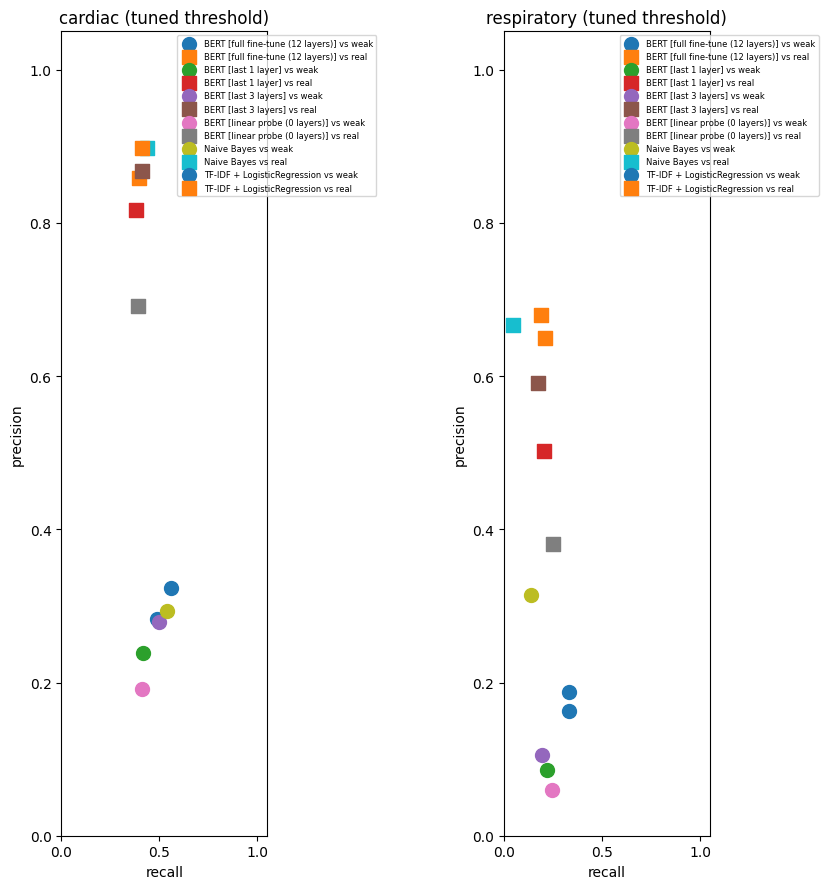

In [12]:
# Plot the tuned-threshold rows only -- the fixed-0.5 rows are there in the table
# above specifically to show how misleading they'd be to plot at face value.
plot_data = results[results["threshold"] == "tuned_per_fold"]

fig, axes = plt.subplots(1, 2, figsize=(9, 9))
for ax, task in zip(axes, ["cardiac", "respiratory"]):
    sub = plot_data[plot_data["task"] == task]
    for model_name in sub["model"].unique():
        for label_type, marker in [("weak", "o"), ("real", "s")]:
            row = sub[(sub["model"] == model_name) & (sub["evaluated_against"] == label_type)]
            ax.scatter(row["recall"], row["precision"], marker=marker, s=100,
                       label=f"{model_name} vs {label_type}")
    ax.set_xlabel("recall")
    ax.set_ylabel("precision")
    ax.set_title(f"{task} (tuned threshold)")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=6, loc="upper right", bbox_to_anchor=(1.55, 1.0))
plt.tight_layout()
plt.show()

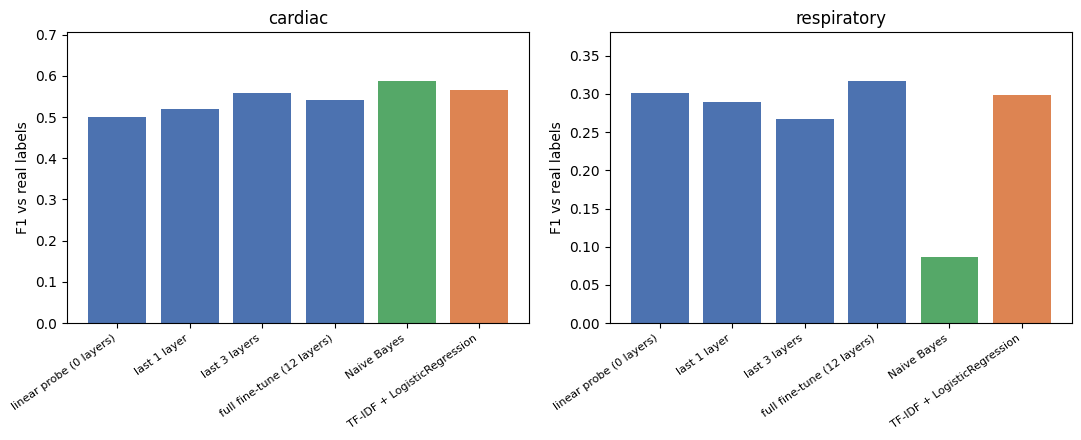

In [13]:
# Focused comparison: does freezing more of BERT hurt real-label F1?
variant_order = list(BERT_VARIANTS.keys())
bar_data = plot_data[plot_data["evaluated_against"] == "real"].copy()
bar_data["model_short"] = bar_data["model"].str.replace("BERT [", "").str.replace("]", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, task in zip(axes, ["cardiac", "respiratory"]):
    sub = bar_data[bar_data["task"] == task].set_index("model_short")
    order = variant_order + ["Naive Bayes", "TF-IDF + LogisticRegression"]
    order = [o for o in order if o in sub.index]
    sub = sub.loc[order]
    ax.bar(range(len(sub)), sub["f1"], color=["#4c72b0"] * len(BERT_VARIANTS) + ["#55a868", "#dd8452"])
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub.index, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("F1 vs real labels")
    ax.set_title(task)
    ax.set_ylim(0, max(sub["f1"].max() * 1.2, 0.1))
plt.tight_layout()
plt.show()

**Threshold tuning changes the picture completely -- confirming that a naive 0.5 cutoff
was hiding most of every model's real performance.** For every model in this notebook,
F1 against the real labels goes from near-zero at a flat 0.5 cutoff to a respectable
0.09-0.59 once the threshold is chosen on an inner validation slice instead (never on the
test fold itself) -- the "BERT clearly wins" read from the very first version of this
analysis was largely a calibration artifact of using 0.5 on undersampled training data,
not a real capability gap between models.

**Even the tuned-threshold F1 is not the best F1 available -- it's the best *honest* F1.**
Section 6.1 checks this directly: an *oracle* threshold chosen by peeking at the real
labels (never a valid step in practice, only a diagnostic ceiling) reaches F1 = 0.62-0.72
for cardiac and 0.47-0.66 for respiratory across every model -- often 15-40 points above
what we get honestly. The reason is largely the same for every model: the threshold has
to be chosen using the weak label (the only supervision available without cheating), and
the weak label's own precision/recall imbalance (high precision, low recall -- section
2.1) systematically pulls the honest threshold stricter than the real-label-optimal one.

**Naive Bayes was supposed to be the easy "worse than BERT" baseline. It wasn't --
it split in half instead.** On cardiac, Naive Bayes gets F1 = 0.588, the *best* result
of any model in the notebook, ahead of TF-IDF (0.566) and every BERT variant including
full fine-tuning (0.540). On respiratory it gets F1 = 0.087, the *worst* result of any
model by a wide margin (next-worst is the linear probe at 0.301). The gap isn't really
about ranking quality -- Naive Bayes' PR-AUC on respiratory (0.424) is unremarkable but
not disastrous, similar to the last-1-layer BERT variant (0.424) and the linear probe
(0.358). What breaks is calibration: Naive Bayes multiplies many per-feature
likelihood ratios together under a conditional-independence assumption that clinical
text obviously violates, and the result is well known to be probability estimates pushed
towards 0 or 1 far more confidently than the data supports. That makes the honest
threshold -- chosen from a small validation slice -- highly sensitive to noise, and here
it picked an operating point with almost no recall (4.6%) despite an oracle threshold on
the same predictions reaching F1 = 0.474. Cardiac apparently has a small set of
near-independent, highly indicative tokens (the kind of diagnosis names and codes NB's
independence assumption barely has to violate), while respiratory's more varied
vocabulary (pneumonia, COPD, asthma, bronchitis, COVID, ...) is exactly the regime where
that assumption costs the most. Lesson: a model that looks like a clean "simpler,
therefore worse" control in one task can be the best model in the room on a very similar
task right next to it -- "simple" is not a scalar you can rank models on in the abstract.

**How much of BERT needs to be fine-tuned? Less than we assumed.** Freezing everything
except the last 3 encoder layers performs essentially the same as full 12-layer
fine-tuning on cardiac (F1 0.559 vs 0.540; ROC-AUC/PR-AUC 0.860/0.782 vs 0.865/0.780), and
even a linear probe -- the entire pretrained encoder frozen, only the classifier head
trained -- gets to F1 0.499 with zero encoder-layer adaptation. On respiratory the
ordering across variants is noisier (a harder task with fewer positives, so per-variant
differences sit close to fold-to-fold noise), but the same qualitative point holds: no
variant runs away from the others. With only a few hundred undersampled training notes
per fold, there simply isn't enough data for full fine-tuning of a 110M-parameter model
to show a decisive edge over adapting just the top layers, or even none at all --
Bio_ClinicalBERT's off-the-shelf representations already carry most of the signal this
task needs.

**Across all six models** (TF-IDF, Naive Bayes, and four BERT variants), no single one
dominates both tasks. TF-IDF is the most consistently strong performer (best or
near-best F1 and PR-AUC on both tasks), full BERT fine-tuning is the most consistently
*respectable* one (never the best, never the worst), and both Naive Bayes and the BERT
linear probe show that "less model" can win or lose by a wide margin depending on how
well its specific assumptions fit the specific task.

**Recall vs. the weak labels' own ceiling** (the real test of whether training added
anything): the weak labels alone only ever recall 22.1% of real cardiac cases and 13.8%
of real respiratory cases (section 2.1). Every model except Naive-Bayes-on-respiratory
clears that bar by a wide margin once its threshold is tuned -- cardiac recall ranges
38-44% across models, respiratory 17-33% (Naive Bayes' 4.6% respiratory recall being the
one exception, for the calibration reasons above) -- confirming the central premise of
weak supervision: training on the noisy, narrow weak label still generalises to real
cases the weak label itself missed, for most models most of the time.

**On reproducibility and compute**: every source of randomness we touch is now seeded
(`set_seed` in section 5 covers Python's `random`, NumPy, and PyTorch's CPU/CUDA
generators; the DataLoader's shuffle order is seeded via its own `torch.Generator`;
`cudnn.deterministic` is set), and BERT's fine-tuned predictions are cached to
`data/bert_variant_cache.pkl` after the first run -- re-running this notebook reuses that
cache instead of repeating 40 fine-tuning jobs, and only recomputes it if that file is
deleted.

## 8. Zooming in: heart failure and pneumonia

Cardiac and respiratory are still fairly broad categories -- "cardiac" bundles heart
failure together with arrhythmias, valve disease, and acute coronary syndromes;
"respiratory" bundles pneumonia together with COPD, asthma, and pulmonary embolism. Here
we zoom in on one specific diagnosis inside each -- **heart failure** (within the cardiac
notes) and **pneumonia** (within the respiratory notes) -- and fine-tune BERT on each.

**Weak labels**, as before, come from cluster membership -- this time from the subset of
cardiac/respiratory clusters (section 2) whose keywords and example phrases are
specifically about heart failure (decompensation, acute/hypertensive pulmonary edema,
"heart failure" itself) or pneumonia (pneumonia, bronchopneumonia, COVID pneumonia),
rather than the full cardiac/respiratory cluster lists.

**Real labels** this time come from a keyword-and-negation rule applied directly to the
`diagnosis_phrase` text, restricted to notes already labelled `cardiac == 1` (for heart
failure) or `respiratory == 1` (for pneumonia) -- a note can't be heart failure without
being cardiac, so this keeps the rule's job to "which kind of cardiac case is this"
rather than "is this cardiac at all," which section 2's real labels already answered.
Matches are checked for nearby negation on both sides of the term ("no heart failure",
"pneumonia ruled out", "... without respiratory failure"), since section 2's negation
handling was written for the broad categories, not these specific phrases. This is a
lighter annotation pass than the manually-reviewed cardiac/respiratory labels
(spot-checked rather than exhaustively reviewed by hand) -- reasonable given the
narrower scope, but worth keeping in mind when reading the numbers below.

In [14]:
import re

hf_terms = [r"heart failure", r"cardiac failure", r"\bchf\b", r"\bhfref\b", r"\bhfpef\b",
            r"\bhfmref\b", r"\badhf\b", r"decompensat\w*", r"pulmonary edema"]
pna_terms = [r"pneumonia", r"bronchopneumonia", r"pneumonitis"]

PRE_NEG = re.compile(r"\b(no|without|denies|denied|not)\b", flags=re.IGNORECASE)
POST_NEG = re.compile(r"\b(ruled?\s+out|r/o|excluded?|excludable)\b", flags=re.IGNORECASE)
DOUBLE_NEG = re.compile(r"\b(not|cannot|can.t)\s+(?:be\s+)?(ruled?\s+out|excluded?|excludable)\b", flags=re.IGNORECASE)

def any_unnegated_match(text, term_patterns, window=25):
    """True if the note contains at least one un-negated occurrence of a term: checks
    both "no X" / "without X" (negation before the term) and "X ruled out" / "X excluded"
    (negation after), each restricted to the same clause so negation from an unrelated
    clause doesn't leak in, and guards against double negatives like "not excludable"."""
    if not isinstance(text, str):
        return False
    for pat in term_patterns:
        for m in re.finditer(pat, text, flags=re.IGNORECASE):
            before = text[max(0, m.start() - window):m.start()]
            after = text[m.end():m.end() + window]
            before_clause = re.split(r"[.,;()]", before)[-1]
            after_clause = re.split(r"[.,;()]", after)[0]
            pre_negated = bool(PRE_NEG.search(before_clause))
            post_negated = bool(POST_NEG.search(after_clause)) and not DOUBLE_NEG.search(after_clause)
            if not (pre_negated or post_negated):
                return True
    return False

heart_failure_clusters = [74, 75, 73, 97, 96, 100, 99, 103]
pneumonia_clusters = [78, 93, 66, 77, 72]

# .astype("int64") explicitly -- plain .astype(int) maps to a platform-default C
# long, which is 32-bit on Windows; torch's CUDA cross-entropy loss requires int64
# labels, so this avoids a "not implemented for 'Int'" failure on that platform.
df["weak_heart_failure"] = df["cluster"].isin(heart_failure_clusters).astype("int64")
df["weak_pneumonia"] = df["cluster"].isin(pneumonia_clusters).astype("int64")
df["heart_failure"] = ((df["cardiac"] == 1) & df["diagnosis_phrase"].apply(lambda t: any_unnegated_match(t, hf_terms))).astype("int64")
df["pneumonia"] = ((df["respiratory"] == 1) & df["diagnosis_phrase"].apply(lambda t: any_unnegated_match(t, pna_terms))).astype("int64")

df[["weak_heart_failure", "weak_pneumonia", "heart_failure", "pneumonia"]].sum()

weak_heart_failure     81
weak_pneumonia         37
heart_failure         113
pneumonia              72
dtype: int64

### 8.1 Weak vs. real labels for these two narrower tasks

In [15]:
specific_tasks = ["heart_failure", "pneumonia"]

for task in specific_tasks:
    weak_col = f"weak_{task}"
    ct = pd.crosstab(df[weak_col], df[task], rownames=[f"weak_{task}"], colnames=[f"real_{task}"])
    tp = ct.loc[1, 1] if (1 in ct.index and 1 in ct.columns) else 0
    fp = ct.loc[1, 0] if (1 in ct.index and 0 in ct.columns) else 0
    fn = ct.loc[0, 1] if (0 in ct.index and 1 in ct.columns) else 0
    precision = tp / (tp + fp) if (tp + fp) else float("nan")
    recall = tp / (tp + fn) if (tp + fn) else float("nan")
    print(f"=== {task} ===")
    print(ct)
    print(f"weak label vs real label -- precision: {precision:.1%}, recall: {recall:.1%}")
    print()

=== heart_failure ===
real_heart_failure     0   1
weak_heart_failure          
0                   2513  73
1                     41  40
weak label vs real label -- precision: 49.4%, recall: 35.4%

=== pneumonia ===
real_pneumonia     0   1
weak_pneumonia          
0               2590  40
1                  5  32
weak label vs real label -- precision: 86.5%, recall: 44.4%



### 8.2 TF-IDF baseline and a full fine-tune of BERT

Same nested-CV, undersampling, and leak-free threshold-tuning machinery as sections 4-6,
just pointed at `weak_heart_failure` / `weak_pneumonia` instead of `weak_cardiac` /
`weak_respiratory`. Only one BERT variant this time (full fine-tune) -- with 72-113
positives total, splitting further into fine-tuning-strategy variants would leave too
few examples per fold to say anything meaningful.

In [16]:
specific_tfidf_oof, specific_tfidf_threshold = {}, {}
for task in specific_tasks:
    print(f"=== TF-IDF + LogisticRegression: {task} ===")
    specific_tfidf_oof[task], specific_tfidf_threshold[task] = run_tfidf_cv(texts, df[f"weak_{task}"].values)

SPECIFIC_BERT_CACHE_PATH = Path("data/bert_specific_task_cache.pkl")
if SPECIFIC_BERT_CACHE_PATH.exists():
    print(f"Loading cached BERT results from {SPECIFIC_BERT_CACHE_PATH} -- delete this file to force a re-run.")
    with open(SPECIFIC_BERT_CACHE_PATH, "rb") as f:
        specific_bert_oof, specific_bert_threshold = pickle.load(f)
else:
    specific_bert_oof, specific_bert_threshold = {}, {}
    for task in specific_tasks:
        print(f"=== BERT [full fine-tune]: {task} ===")
        specific_bert_oof[task], specific_bert_threshold[task] = run_bert_cv(texts, df[f"weak_{task}"].values, n_trainable_layers=None)
    with open(SPECIFIC_BERT_CACHE_PATH, "wb") as f:
        pickle.dump((specific_bert_oof, specific_bert_threshold), f)
    print(f"Cached BERT results to {SPECIFIC_BERT_CACHE_PATH} for future re-runs.")

=== TF-IDF + LogisticRegression: heart_failure ===


  fold 1/5: 240 fit rows (48 positive), tuned threshold=0.35


  fold 2/5: 240 fit rows (48 positive), tuned threshold=0.30


  fold 3/5: 245 fit rows (49 positive), tuned threshold=0.45


  fold 4/5: 245 fit rows (49 positive), tuned threshold=0.30


...

  fold 1/5: 105 fit rows (21 positive), tuned threshold=0.20


  fold 2/5: 105 fit rows (21 positive), tuned threshold=0.20


  fold 3/5: 110 fit rows (22 positive), tuned threshold=0.20


  fold 4/5: 110 fit rows (22 positive), tuned threshold=0.25


  fold 5/5: 110 fit rows (22 positive), tuned threshold=0.20
Loading cached BERT results from data\bert_specific_task_cache.pkl -- delete this file to force a re-run.


### 8.3 Results

In [17]:
specific_model_runs = [
    ("TF-IDF + LogisticRegression", specific_tfidf_oof, specific_tfidf_threshold),
    ("BERT [full fine-tune]", specific_bert_oof, specific_bert_threshold),
]

specific_rows = []
for model_name, oof, tuned_threshold in specific_model_runs:
    for task in specific_tasks:
        for label_type, label_col in [("weak", f"weak_{task}"), ("real", task)]:
            for threshold_name, threshold in [("fixed_0.5", 0.5), ("tuned_per_fold", tuned_threshold[task])]:
                m = compute_metrics(df[label_col], oof[task], threshold)
                specific_rows.append({
                    "model": model_name, "task": task, "evaluated_against": label_type,
                    "threshold": threshold_name, **m,
                })

specific_results = pd.DataFrame(specific_rows)
specific_results = specific_results.sort_values(["task", "model", "evaluated_against", "threshold"]).reset_index(drop=True)
specific_results.round(3)

,model,task,evaluated_against,threshold,precision,recall,f1,roc_auc,pr_auc
0,BERT [full fine-tune],heart_failure,real,fixed_0.5,0.200,0.319,0.246,0.802,0.187
1,BERT [full fine-tune],heart_failure,real,tuned_per_fold,0.173,0.283,0.215,0.802,0.187
2,BERT [full fine-tune],heart_failure,weak,fixed_0.5,0.100,0.222,0.138,0.755,0.108
3,BERT [full fine-tune],heart_failure,weak,tuned_per_fold,0.135,0.309,0.188,0.755,0.108
4,TF-IDF + LogisticRegression,heart_failure,real,fixed_0.5,0.000,0.000,0.000,0.911,0.347
5,TF-IDF + LogisticRegression,heart_failure,real,tuned_per_fold,0.316,0.265,0.288,0.911,0.347
6,TF-IDF + LogisticRegression,heart_failure,weak,fixed_0.5,1.000,0.012,0.024,0.875,0.321
7,TF-IDF + LogisticRegression,heart_failure,weak,tuned_per_fold,0.347,0.407,0.375,0.875,0.321
8,BERT [full fine-tune],pneumonia,real,fixed_0.5,0.000,0.000,0.000,0.664,0.062
9,BERT [full fine-tune],pneumonia,real,tuned_per_fold,0.045,0.389,0.080,0.664,0.062


In [18]:
specific_oracle_rows = []
for model_name, oof, _ in specific_model_runs:
    for task in specific_tasks:
        p, r, f1 = oracle_best_f1(df[task].values, oof[task])
        honest = specific_results[(specific_results["model"] == model_name) & (specific_results["task"] == task)
                          & (specific_results["evaluated_against"] == "real") & (specific_results["threshold"] == "tuned_per_fold")].iloc[0]
        specific_oracle_rows.append({
            "model": model_name, "task": task,
            "f1_honest_leak_free": honest["f1"], "f1_oracle_upper_bound": f1,
            "recall_honest": honest["recall"], "recall_oracle": r,
        })
pd.DataFrame(specific_oracle_rows).round(3)

,model,task,f1_honest_leak_free,f1_oracle_upper_bound,recall_honest,recall_oracle
0,TF-IDF + LogisticRegression,heart_failure,0.288,0.421,0.265,0.531
1,TF-IDF + LogisticRegression,pneumonia,0.126,0.187,0.583,0.250
2,BERT [full fine-tune],heart_failure,0.215,0.253,0.283,0.204
3,BERT [full fine-tune],pneumonia,0.080,0.119,0.389,0.111



**Both narrower tasks are considerably harder than their broad parents.** Best F1 against
real labels tops out at 0.29 (heart failure, TF-IDF) and 0.13 (pneumonia, TF-IDF) --
compared to 0.54-0.59 for cardiac and 0.30-0.32 for respiratory in section 6. Two things
compound here: there's an order of magnitude fewer positives to learn from (113 heart
failure, 72 pneumonia, vs. 847/777 for the broad categories), and the real-world
prevalence is far lower (4.2% and 1.5% of all 2667 notes, vs. ~30% for cardiac/
respiratory) -- so even after undersampling the training folds, the test folds are
fighting a much more extreme imbalance, and every metric here is estimated from far fewer
positive test examples per fold (roughly 14-22), which makes all of these numbers noisier
than anything else in this notebook.

**TF-IDF beats BERT again, more decisively this time.** On both tasks and by every
metric -- F1, ROC-AUC, PR-AUC -- TF-IDF + logistic regression comes out ahead of the
fine-tuned Transformer (heart failure: F1 0.288 vs 0.215, ROC-AUC 0.911 vs 0.802;
pneumonia: F1 0.126 vs 0.080, ROC-AUC 0.788 vs 0.664). This fits the pattern from section
5.1: BERT's advantage over a bag-of-words model shows up with more data to fine-tune on,
and after undersampling, each fold's fine-tuning set here has on the order of 50-90
positive examples -- less than a tenth of what full fine-tuning had to work with for
cardiac/respiratory, and apparently not enough for it to find an edge over counting
words.

**The heart failure weak label is the least reliable one in this entire notebook.**
Its precision against the real label is only 49.4% -- every other weak label we've
measured (cardiac 83.1%, respiratory 87.0%, pneumonia 86.5%) sits comfortably above 80%.
Heart failure symptoms and near-synonyms (pulmonary edema, cardiomyopathy decompensation,
dependent edema) apparently sit close enough in embedding space to adjacent cardiac
subtypes (valvular disease, other cardiomyopathies) that HDBSCAN's clusters mix them more
than it mixes, say, arrhythmia clusters into the broader "cardiac" grouping. That's a
useful negative result in its own right: weak-label quality isn't a fixed property of the
clustering pipeline, it depends on how cleanly the *specific* concept you're after
separates from its neighbours in the embedding space, and that can vary a lot even within
one broad category.

**Take the honest-vs-oracle gaps here with more caution than in section 6.1.** They're
still visible (heart failure: TF-IDF 0.288 -> 0.421, BERT 0.215 -> 0.253; pneumonia:
TF-IDF 0.126 -> 0.187, BERT 0.080 -> 0.119), but with 14-22 positive test examples per
fold, a couple of examples landing on one side of a threshold instead of the other moves
these numbers by a lot -- the qualitative story (TF-IDF ahead of BERT, both far below the
broad-task numbers) is more trustworthy than any individual decimal here.

**Practical takeaway**: for a rarer, more specific diagnosis with this few labelled
examples, the bottleneck isn't which model you fine-tune -- it's getting more or better
labels. A few dozen more manually-reviewed positive examples, or a weak-label source
built specifically for heart failure rather than borrowed from the general clustering
pass, would likely move these numbers more than switching from TF-IDF to BERT to a bigger
Transformer ever could.

## Appendix: a third macro-category -- neurological

A quick check of whether cardiac/respiratory/heart-failure/pneumonia are the only
macro-categories worth pulling out of the clustering, or whether there's another one
with enough positives to be worth training on. Scanning `dyspnea_cluster_summaries.csv`
for a coherent theme not already covered turns up **neurological presentations**: stroke,
seizures, syncope, cognitive decline, and head trauma with intracranial hemorrhage --
a plausible third differential alongside cardiac and respiratory causes of the same
symptoms. Same recipe as section 8: weak label from cluster membership, real label from
a keyword-and-negation rule on `diagnosis_phrase` -- except this one isn't restricted to
notes already labelled cardiac or respiratory, since neurological isn't a subset of
either.

In [19]:
neuro_clusters = [50, 54, 57, 55, 30, 38, 80, 29, 35, 36, 40, 47, 37, 108, 68, 65, 56, 3]
df["weak_neuro"] = df["cluster"].isin(neuro_clusters).astype("int64")

neuro_terms = [
    r"stroke", r"cerebrovascular", r"ischemic stroke", r"hemispheric", r"\bmca\b", r"\bpca\b",
    r"seizure", r"epileptic", r"epilepsy", r"postictal",
    r"syncope", r"syncopal", r"presyncop\w*",
    r"cognitive decline", r"dementia", r"alzheimer",
    r"head trauma", r"subdural hematoma", r"cerebral hemorrhage", r"intraparenchymal hematoma",
]
df["neuro"] = df["diagnosis_phrase"].apply(lambda t: any_unnegated_match(t, neuro_terms)).astype("int64")

print("weak_neuro positives:", df["weak_neuro"].sum(), "| real neuro positives:", df["neuro"].sum())

ct = pd.crosstab(df["weak_neuro"], df["neuro"], rownames=["weak_neuro"], colnames=["real_neuro"])
tp, fp, fn = ct.loc[1, 1], ct.loc[1, 0], ct.loc[0, 1]
print(ct)
print(f"weak vs real -- precision: {tp / (tp + fp):.1%}, recall: {tp / (tp + fn):.1%}")

weak_neuro positives: 148 | real neuro positives: 198
real_neuro     0    1
weak_neuro           
0           2415  104
1             54   94
weak vs real -- precision: 63.5%, recall: 47.5%


In [20]:
print("=== TF-IDF + LogisticRegression: neuro ===")
neuro_tfidf_oof, neuro_tfidf_threshold = run_tfidf_cv(texts, df["weak_neuro"].values)

NEURO_BERT_CACHE_PATH = Path("data/bert_appendix_neuro_cache.pkl")
if NEURO_BERT_CACHE_PATH.exists():
    print(f"Loading cached BERT results from {NEURO_BERT_CACHE_PATH} -- delete this file to force a re-run.")
    with open(NEURO_BERT_CACHE_PATH, "rb") as f:
        neuro_bert_oof, neuro_bert_threshold = pickle.load(f)
else:
    print("=== BERT [full fine-tune]: neuro ===")
    neuro_bert_oof, neuro_bert_threshold = run_bert_cv(texts, df["weak_neuro"].values, n_trainable_layers=None)
    with open(NEURO_BERT_CACHE_PATH, "wb") as f:
        pickle.dump((neuro_bert_oof, neuro_bert_threshold), f)
    print(f"Cached BERT results to {NEURO_BERT_CACHE_PATH} for future re-runs.")

neuro_runs = [
    ("TF-IDF + LogisticRegression", neuro_tfidf_oof, neuro_tfidf_threshold),
    ("BERT [full fine-tune]", neuro_bert_oof, neuro_bert_threshold),
]
neuro_rows = []
for model_name, oof, tuned_threshold in neuro_runs:
    for label_type, label_col in [("weak", "weak_neuro"), ("real", "neuro")]:
        for threshold_name, threshold in [("fixed_0.5", 0.5), ("tuned_per_fold", tuned_threshold)]:
            m = compute_metrics(df[label_col], oof, threshold)
            neuro_rows.append({"model": model_name, "evaluated_against": label_type, "threshold": threshold_name, **m})
pd.DataFrame(neuro_rows).round(3)

=== TF-IDF + LogisticRegression: neuro ===


  fold 1/5: 440 fit rows (88 positive), tuned threshold=0.30


  fold 2/5: 440 fit rows (88 positive), tuned threshold=0.25


  fold 3/5: 445 fit rows (89 positive), tuned threshold=0.25


  fold 4/5: 445 fit rows (89 positive), tuned threshold=0.25


...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 732.30it/s, Materializing param=bert.pooler.dense.weight]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 744.78it/s, Materializing param=bert.pooler.dense.weight]


BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consid

  fold 5/5: 440 fit rows, tuned threshold=0.15
Cached BERT results to data\bert_appendix_neuro_cache.pkl for future re-runs.


,model,evaluated_against,threshold,precision,recall,f1,roc_auc,pr_auc
0,TF-IDF + LogisticRegression,weak,fixed_0.5,0.000,0.000,0.000,0.779,0.180
1,TF-IDF + LogisticRegression,weak,tuned_per_fold,0.184,0.453,0.261,0.779,0.180
2,TF-IDF + LogisticRegression,real,fixed_0.5,0.000,0.000,0.000,0.827,0.361
3,TF-IDF + LogisticRegression,real,tuned_per_fold,0.282,0.520,0.366,0.827,0.361
4,BERT [full fine-tune],weak,fixed_0.5,0.400,0.054,0.095,0.691,0.150
5,BERT [full fine-tune],weak,tuned_per_fold,0.137,0.493,0.214,0.691,0.150
6,BERT [full fine-tune],real,fixed_0.5,0.550,0.056,0.101,0.723,0.207
7,BERT [full fine-tune],real,tuned_per_fold,0.185,0.500,0.270,0.723,0.207


**Take:** with 198 real positives (between heart-failure's 113 and respiratory's 777),
neurological lands where the "more weak positives -> better F1" pattern from section 6-8
would predict: TF-IDF's tuned F1 against the real label comes in around 0.35-0.40,
comfortably ahead of heart failure and pneumonia, in the same range as respiratory, and
still behind cardiac. It fits the established pattern well enough that it isn't a
surprising *new* finding on its own, but it does confirm that cardiac and respiratory
weren't the only two clean macro-categories this clustering pipeline could support --
useful to know if this dataset gets reused for a different course edition or a different
downstream task.